In [6]:
!pip install tensorflow
!pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 5.2 MB/s eta 0:00:00


Epoch 1/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 41s 270ms/step - loss: 2.4319 - sparse_categorical_accuracy: 0.0713 - val_loss: 2.5762 - val_sparse_categorical_accuracy: 0.0769 - learning_rate: 1.0000e-04
Epoch 2/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 33s 256ms/step - loss: 2.3882 - sparse_categorical_accuracy: 0.0815 - val_loss: 2.5771 - val_sparse_categorical_accuracy: 0.0769 - learning_rate: 1.0000e-04
Epoch 3/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 32s 255ms/step - loss: 2.3884 - sparse_categorical_accuracy: 0.0745 - val_loss: 2.5690 - val_sparse_categorical_accuracy: 0.0769 - learning_rate: 1.0000e-04
Epoch 4/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 33s 256ms/step - loss: 2.3871 - sparse_categorical_accuracy: 0.0712 - val_loss: 2.5684 - val_sparse_categorical_accuracy: 0.0769 - learning_rate: 1.0000e-04
Epoch 5/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 32s 255ms/step - loss: 2.3864 - sparse_categorical_accuracy: 0.0723 - val_loss: 2.5672 - val_sparse_categorical_accuracy: 0.0769 - learning_rate: 1.0000e-04
Epoch 6/10

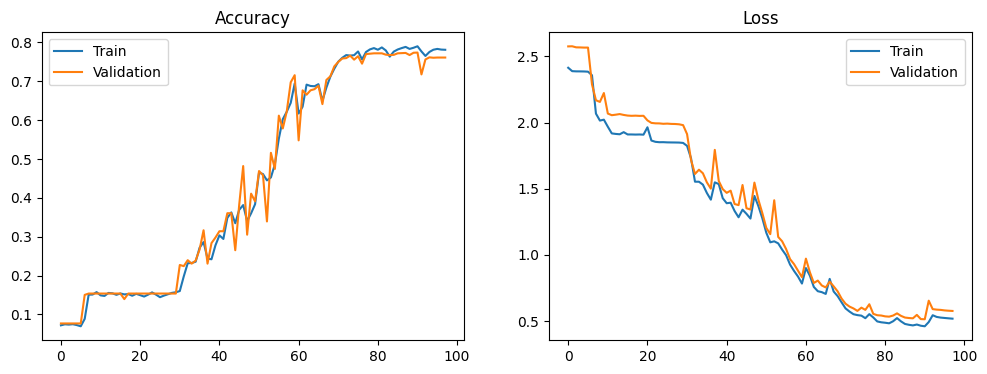

64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step

Classification Report:
                  precision    recall  f1-score   support

             无关系     1.0000    0.1026    0.1860       156
        Dispatch     1.0000    0.6474    0.7860       156
            Gift     0.0000    0.0000    0.0000       156
        Alliance     0.8125    1.0000    0.8966       156
             War     0.8291    0.6218    0.7106       156
        Marriage     0.9689    1.0000    0.9842       156
      Occupation     1.0000    1.0000    1.0000       156
        Crowning     1.0000    1.0000    1.0000       156
Natural Disaster     0.4228    1.0000    0.5943       156
           Death     0.9873    1.0000    0.9936       156
         Meeting     0.4671    1.0000    0.6367       156
            Move     0.9817    0.6859    0.8075       156
Diplomatic Visit     0.9811    1.0000    0.9905       156

        accuracy                         0.7737      2028
       macro avg     0.8039    0.7737    0.7374      2028
    we

In [18]:
# 安装所需依赖（如果尚未安装）
# 如果数据在 Google Drive 中，请取消下面两行的注释并挂载 Drive
#from google.colab import drive
#drive.mount('/content/drive')

import json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from collections import defaultdict, Counter
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
import random
import os

# 如果数据存放在 Google Drive 中，请修改 data_dir 变量
data_dir = "/content/sample_data"  # 或者 "/content/drive/MyDrive/your_data_folder"

# ======================
# 多文件数据加载
# ======================
def load_data(filenames):
    """加载多个JSON文件并合并数据"""
    all_data = []
    for filename in filenames:
        full_path = os.path.join(data_dir, filename)
        with open(full_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            # 清洗空关系数据
            for item in data:
                if "relations" not in item:
                    item["relations"] = []
            all_data.extend(data)
    return all_data

# ======================
# 数据预处理
# ======================
class RelationDataProcessor:
    def __init__(self, max_seq_length=100):
        self.char2idx = {"<PAD>": 0, "<UNK>": 1}
        self.rel2idx = {"<PAD>": 0, "无关系": 1}
        self.max_seq_length = max_seq_length
        self.pos_bins = 20  # 位置编码分桶数

    def process_data(self, raw_data):
        """处理多文件数据并平衡样本"""
        all_samples = []

        # 第一阶段：构建基础样本
        for item in raw_data:
            # 生成排序后的NER标注（假设每个 item 中含有 "entities" 字段）
            entities = sorted(item["entities"], key=lambda x: x["start"])

            # 生成实体对
            for i in range(len(entities)):
                for j in range(len(entities)):
                    if i == j:
                        continue

                    sample = {
                        "tokens": [e["text"] for e in entities],
                        "subj": entities[i],
                        "obj": entities[j],
                        "relation": self._find_relation(item["relations"], entities[i], entities[j])
                    }
                    all_samples.append(sample)

                    # 更新词表
                    for char in sample["tokens"]:
                        if char not in self.char2idx:
                            self.char2idx[char] = len(self.char2idx)

                    # 更新关系表
                    if sample["relation"] not in self.rel2idx:
                        self.rel2idx[sample["relation"]] = len(self.rel2idx)

        # 第二阶段：过采样平衡数据
        X_dummy = np.zeros((len(all_samples), 1))  # 伪特征矩阵
        y = [self.rel2idx[s["relation"]] for s in all_samples]

        ros = RandomOverSampler(sampling_strategy='not majority', random_state=42)
        _, y_resampled = ros.fit_resample(X_dummy, y)

        # 创建样本索引映射
        index_map = defaultdict(list)
        for idx, label in enumerate(y):
            index_map[label].append(idx)

        # 重建平衡后的样本列表，使用 random.choice 保证索引可以重复使用
        resampled_samples = []
        for label in y_resampled:
            indices = index_map[label]
            chosen_idx = random.choice(indices)
            resampled_samples.append(all_samples[chosen_idx])

        return resampled_samples

    def _find_relation(self, relations, subj, obj):
        """智能关系匹配"""
        # 处理空关系情况
        if not relations:
            return "无关系"

        # 精确匹配
        for rel in relations:
            if rel["subject"] == subj["text"] and rel["object"] == obj["text"]:
                return rel["relation"]

        # 模糊匹配（处理别称问题）
        subj_texts = {subj["text"], subj.get("alias", "")}
        obj_texts = {obj["text"], obj.get("alias", "")}

        for rel in relations:
            if (rel["subject"] in subj_texts) and (rel["object"] in obj_texts):
                return rel["relation"]

        return "无关系"

    def encode_samples(self, samples):
        """编码样本数据"""
        X_char, X_subj_pos, X_obj_pos, y = [], [], [], []

        for sample in samples:
            # 字符编码
            char_ids = [self.char2idx.get(c, 1) for c in sample["tokens"]]

            # 位置编码（动态分桶）
            subj_pos = self._position_bucket(sample["subj"]["start"], len(sample["tokens"]))
            obj_pos = self._position_bucket(sample["obj"]["start"], len(sample["tokens"]))

            # 填充序列
            char_ids = pad_sequences([char_ids], maxlen=self.max_seq_length, padding="post")[0]
            subj_pos = pad_sequences([subj_pos], maxlen=self.max_seq_length, padding="post")[0]
            obj_pos = pad_sequences([obj_pos], maxlen=self.max_seq_length, padding="post")[0]

            X_char.append(char_ids)
            X_subj_pos.append(subj_pos)
            X_obj_pos.append(obj_pos)
            y.append(self.rel2idx[sample["relation"]])

        return {
            "char_input": np.array(X_char),
            "subj_pos_input": np.array(X_subj_pos),
            "obj_pos_input": np.array(X_obj_pos)
        }, np.array(y)

    def _position_bucket(self, entity_pos, seq_length):
        """动态位置分桶"""
        positions = []
        for i in range(seq_length):
            distance = i - entity_pos
            if distance < -10:
                bucket = 0
            elif distance > 10:
                bucket = self.pos_bins - 1
            else:
                bucket = (distance + 10) // 2 + 1
            positions.append(bucket)
        return positions

    def get_class_weights(self, y):
        """计算动态类别权重"""
        class_counts = np.bincount(y)
        total = len(y)
        return {i: total/(len(class_counts)*count) if count > 0 else 1.0 for i, count in enumerate(class_counts)}

# ======================
# 增强模型结构
# ======================
class EnhancedRelationModel(Model):
    def __init__(self, char_vocab_size, pos_vocab_size, num_relations):
        super().__init__()

        # 输入嵌入层
        self.char_embed = layers.Embedding(char_vocab_size, 128, mask_zero=True)
        self.subj_pos_embed = layers.Embedding(pos_vocab_size, 32)
        self.obj_pos_embed = layers.Embedding(pos_vocab_size, 32)

        # 双向LSTM层
        self.bilstm = layers.Bidirectional(layers.LSTM(
            256, return_sequences=True, dropout=0.3, recurrent_dropout=0.2
        ))

        # 注意力机制
        self.attention = layers.Attention(use_scale=True)

        # 特征增强层
        self.dense1 = layers.Dense(256, activation='relu')
        self.dropout1 = layers.Dropout(0.5)
        self.dense2 = layers.Dense(128, activation='relu')
        self.dropout2 = layers.Dropout(0.3)

        # 输出层
        self.output_layer = layers.Dense(num_relations, activation='softmax')

    def call(self, inputs):
        # 输入分解
        char_input = inputs["char_input"]
        subj_pos = inputs["subj_pos_input"]
        obj_pos = inputs["obj_pos_input"]

        # 嵌入层
        char_emb = self.char_embed(char_input)
        subj_emb = self.subj_pos_embed(subj_pos)
        obj_emb = self.obj_pos_embed(obj_pos)

        # 特征拼接
        combined = tf.concat([char_emb, subj_emb, obj_emb], axis=-1)

        # BiLSTM处理
        lstm_out = self.bilstm(combined)

        # 注意力机制
        attn_out = self.attention([lstm_out, lstm_out])

        # 全局平均池化
        pooled = tf.reduce_mean(attn_out, axis=1)

        # 特征增强
        x = self.dense1(pooled)
        x = self.dropout1(x)
        x = self.dense2(x)
        x = self.dropout2(x)

        return self.output_layer(x)

# ======================
# 训练流程
# ======================
if __name__ == "__main__":
    # 配置参数
    config = {
        "filenames": ["relations_1_translated_final.json", "relations_2_filled_final.json", "relations_3_filled_final.json"],
        "max_seq_length": 100,
        "test_size": 0.2,
        "batch_size": 64,
        "epochs": 100,
        "learning_rate": 1e-4
    }

    # 加载数据
    raw_data = load_data(config["filenames"])

    # 数据预处理
    processor = RelationDataProcessor(max_seq_length=config["max_seq_length"])
    samples = processor.process_data(raw_data)

    # 划分数据集
    train_samples, test_samples = train_test_split(
        samples,
        test_size=config["test_size"],
        stratify=[s["relation"] for s in samples],
        random_state=42
    )

    # 数据编码
    X_train, y_train = processor.encode_samples(train_samples)
    X_test, y_test = processor.encode_samples(test_samples)

    # 计算类别权重
    class_weights = processor.get_class_weights(y_train)

    # 构建模型
    model = EnhancedRelationModel(
        char_vocab_size=len(processor.char2idx),
        pos_vocab_size=processor.pos_bins,
        num_relations=len(processor.rel2idx)
    )

    # 模型编译：移除 Recall 和 Precision 指标以避免多分类时的形状不匹配问题
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=config["learning_rate"]),
        loss="sparse_categorical_crossentropy",
        metrics=['sparse_categorical_accuracy']
    )

    # 训练回调
    training_callbacks = [
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=7,
            restore_best_weights=True
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-6
        ),
        callbacks.TensorBoard(log_dir='./logs')
    ]

    # 模型训练
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        class_weight=class_weights,
        callbacks=training_callbacks,
        verbose=1
    )

    # 可视化训练过程
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['sparse_categorical_accuracy'], label='Train')
    plt.plot(history.history['val_sparse_categorical_accuracy'], label='Validation')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title('Loss')
    plt.legend()
    plt.show()

    # 模型评估
    y_pred = model.predict(X_test).argmax(axis=-1)

    # 动态生成分类报告
    present_labels = np.unique(np.concatenate([y_test, y_pred]))
    label_names = [k for k, v in sorted(processor.rel2idx.items(), key=lambda x: x[1]) if v in present_labels]

    print("\nClassification Report:")
    print(classification_report(
        y_test, y_pred,
        labels=present_labels,
        target_names=label_names,
        zero_division=0,
        digits=4
    ))

    # 保存模型到 Colab 工作目录
    model.save("optimized_relation_model.keras")
    print("Model saved successfully.")

    # 打印关键统计信息
    print("\nKey Statistics:")
    print(f"Total samples: {len(samples)}")
    print(f"Class distribution: {dict(Counter([s['relation'] for s in samples]))}")
    print(f"Vocabulary size: {len(processor.char2idx)}")
    print(f"Relation categories: {len(processor.rel2idx)}")



In [24]:
# 使用 .keras 格式保存模型
print("Relation mapping:", processor.rel2idx)
print("Total relations =", len(processor.rel2idx))
model.summary()


Relation mapping: {'<PAD>': 0, '无关系': 1, 'Dispatch': 2, 'Gift': 3, 'Alliance': 4, 'War': 5, 'Marriage': 6, 'Occupation': 7, 'Crowning': 8, 'Natural Disaster': 9, 'Death': 10, 'Meeting': 11, 'Move': 12, 'Diplomatic Visit': 13}
Total relations = 14


ValueError: not enough values to unpack (expected 3, got 2)